# Axis of Awesome — Chord Progression Analysis

**Research question:** How many songs across three collections (*lastfm*, *suno*, *udio*) are based on the **Axis of Awesome** chord progression?

## The Axis progression is a SEQUENCE, not a vocabulary

The Axis of Awesome is the **cyclic loop** I → V → vi → IV (and its minor equivalents).  
A song is "axis-based" when this loop **repeats as the harmonic structure** — not merely because it uses the chords I, V, vi, IV (which are the 4 most common chords in Western music).

## Method

1. **Define axis rotations** — 4 cyclic rotations per set (12 total), NOT all 24 permutations  
2. **Scan 4-chord sliding windows** — on the collapsed chord sequence (consecutive duplicates removed)  
3. **Compute window match rate** — `axis_windows / total_windows` per song  
4. **Classify** — a song is "axis-based" when ≥ 50 % of its windows match an axis rotation (= the loop dominates the song's harmony)  
5. **Compare collections** — distribution of match rates across the three corpora

In [2]:
import os, re
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']
colors = {'lastfm': '#51BFFF', 'suno': '#FFC400', 'udio': '#FF5B0E'}

# ═══════════════════════════════════════════════════════════════════════════════
# 12-TONE CHORD NORMALISER
# ═══════════════════════════════════════════════════════════════════════════════
_DEG_SEMI = {'I': 0, 'II': 2, 'III': 4, 'IV': 5, 'V': 7, 'VI': 9, 'VII': 11}
_SEMI_MAJ = {0:'I', 1:'bII', 2:'II', 3:'bIII', 4:'III', 5:'IV',
             6:'#IV', 7:'V', 8:'bVI', 9:'VI', 10:'bVII', 11:'VII'}
_SEMI_MIN = {0:'i', 1:'bii', 2:'ii', 3:'biii', 4:'iii', 5:'iv',
             6:'#iv', 7:'v', 8:'bvi', 9:'vi', 10:'bvii', 11:'vii'}
_CHORD_RE = re.compile(
    r'^([#b]*)(VII|VI|V|IV|III|II|I|vii|vi|v|iv|iii|ii|i)$')

def normalize_chord(ch):
    """Resolve enharmonics via 12-tone semitone mapping."""
    norm = re.sub(r'^B(?=[IViv])', 'b', ch)
    m = _CHORD_RE.match(norm)
    if not m:
        return ch
    acc_str, deg = m.group(1), m.group(2)
    acc = acc_str.count('#') - acc_str.count('b')
    is_minor = deg[0].islower()
    semi = (_DEG_SEMI[deg.upper()] + acc) % 12
    return _SEMI_MIN[semi] if is_minor else _SEMI_MAJ[semi]

for inp, exp in [('#V','bVI'),('#VII','I'),('##IV','V'),('BVII','bVII'),
                 ('BVI','bVI'),('bVI','bVI'),('I','I'),('vi','vi')]:
    assert normalize_chord(inp) == exp, f'{inp} → {normalize_chord(inp)} ≠ {exp}'

# ═══════════════════════════════════════════════════════════════════════════════
# AXIS OF AWESOME — 3 chord sets, ALL PERMUTATIONS
# ═══════════════════════════════════════════════════════════════════════════════
import itertools

AXIS_CHORD_SETS = [
    ('I', 'V', 'vi', 'IV'),           # major
    ('i', 'bVI', 'III', 'bVII'),      # minor
    ('i', 'bVI', 'bIII', 'bVII'),     # minor variant
]
AXIS_SET_LABELS = ['major', 'minor', 'minor variant']

# All permutations per set — any ordering of the axis chords is valid
AXIS_ROTATIONS = set()
for axis_set in AXIS_CHORD_SETS:
    for perm in itertools.permutations(axis_set):
        AXIS_ROTATIONS.add(perm)

# Axis vocabulary (for secondary descriptive stats only)
AXIS_VOCAB = set()
for s in AXIS_CHORD_SETS:
    AXIS_VOCAB |= set(s)

# ═══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def parse_functional_lab(path):
    """Parse _functional.lab → list of normalised chord labels."""
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(normalize_chord(parts[2]))
    return labels

def collapse_repeats(seq):
    """Remove consecutive duplicates: [I,I,V,V,vi] → [I,V,vi]"""
    if not seq:
        return []
    out = [seq[0]]
    for s in seq[1:]:
        if s != out[-1]:
            out.append(s)
    return out

def axis_window_match_rate(collapsed):
    """Slide a 4-chord window over the collapsed sequence.
    Return (n_matches, n_windows, match_rate_pct)."""
    if len(collapsed) < 4:
        return 0, 0, 0.0
    n_windows = len(collapsed) - 3
    n_matches = 0
    for i in range(n_windows):
        window = tuple(collapsed[i:i+4])
        if window in AXIS_ROTATIONS:
            n_matches += 1
    rate = n_matches / n_windows * 100 if n_windows > 0 else 0.0
    return n_matches, n_windows, rate

# ── Summary ──
print(f'Axis chord sets: {len(AXIS_CHORD_SETS)}')
print(f'All valid axis permutations: {len(AXIS_ROTATIONS)}')
print(f'Normaliser checks passed ✓')
print('Setup complete')

Axis chord sets: 3
All valid axis permutations: 72
Normaliser checks passed ✓
Setup complete


## Step 1 — The axis permutations

Any ordering of the axis chord set is a valid axis pattern.  
All 24 permutations per set are accepted.

In [3]:
# ============================================================
# STEP 1 — Show all valid axis permutations
# ============================================================

for idx, (axis_set, label) in enumerate(zip(AXIS_CHORD_SETS, AXIS_SET_LABELS)):
    print(f'━━ Set {idx} ({label}): {list(axis_set)} ━━')
    for perm in sorted(itertools.permutations(axis_set)):
        print(f'  {"→".join(perm)}')
    print()

print(f'TOTAL valid axis permutations: {len(AXIS_ROTATIONS)}')

━━ Set 0 (major): ['I', 'V', 'vi', 'IV'] ━━
  I→IV→V→vi
  I→IV→vi→V
  I→V→IV→vi
  I→V→vi→IV
  I→vi→IV→V
  I→vi→V→IV
  IV→I→V→vi
  IV→I→vi→V
  IV→V→I→vi
  IV→V→vi→I
  IV→vi→I→V
  IV→vi→V→I
  V→I→IV→vi
  V→I→vi→IV
  V→IV→I→vi
  V→IV→vi→I
  V→vi→I→IV
  V→vi→IV→I
  vi→I→IV→V
  vi→I→V→IV
  vi→IV→I→V
  vi→IV→V→I
  vi→V→I→IV
  vi→V→IV→I

━━ Set 1 (minor): ['i', 'bVI', 'III', 'bVII'] ━━
  III→bVI→bVII→i
  III→bVI→i→bVII
  III→bVII→bVI→i
  III→bVII→i→bVI
  III→i→bVI→bVII
  III→i→bVII→bVI
  bVI→III→bVII→i
  bVI→III→i→bVII
  bVI→bVII→III→i
  bVI→bVII→i→III
  bVI→i→III→bVII
  bVI→i→bVII→III
  bVII→III→bVI→i
  bVII→III→i→bVI
  bVII→bVI→III→i
  bVII→bVI→i→III
  bVII→i→III→bVI
  bVII→i→bVI→III
  i→III→bVI→bVII
  i→III→bVII→bVI
  i→bVI→III→bVII
  i→bVI→bVII→III
  i→bVII→III→bVI
  i→bVII→bVI→III

━━ Set 2 (minor variant): ['i', 'bVI', 'bIII', 'bVII'] ━━
  bIII→bVI→bVII→i
  bIII→bVI→i→bVII
  bIII→bVII→bVI→i
  bIII→bVII→i→bVI
  bIII→i→bVI→bVII
  bIII→i→bVII→bVI
  bVI→bIII→bVII→i
  bVI→bIII→i→bVII
  bVI→b

## Step 2 — Scan every song: 4-chord sliding window match rate

For each song:
1. Parse and normalise chords, collapse consecutive duplicates  
2. Slide a **4-chord window** across the sequence  
3. Check each window against **all valid axis permutations**  
4. Compute **match rate** = axis_windows / total_windows  

This measures whether the song's harmonic structure uses the axis chord set — any ordering is valid.

In [4]:
# ============================================================
# STEP 2 — Scan all songs: 4-chord window match rate
# ============================================================

total_songs   = {}
all_song_data = {}

for col in COLLECTIONS:
    root = os.path.join(BASE_DIR, col)
    songs = []
    for song_id in sorted(os.listdir(root)):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue

        chords = parse_functional_lab(fp)
        collapsed = collapse_repeats(chords)
        n_matches, n_windows, match_rate = axis_window_match_rate(collapsed)

        # Also compute vocabulary % for secondary comparison
        if chords:
            vocab_pct = sum(1 for ch in chords if ch in AXIS_VOCAB) / len(chords) * 100
        else:
            vocab_pct = 0.0

        songs.append({
            'file': song_id,
            'n_chords': len(chords),
            'n_collapsed': len(collapsed),
            'axis_matches': n_matches,
            'axis_windows': n_windows,
            'match_rate': match_rate,       # ← PRIMARY METRIC
            'vocab_pct': vocab_pct,         # ← secondary
        })

    total_songs[col] = len(songs)
    all_song_data[col] = songs

# Report
print('Step 2 — 4-chord window scan complete')
print(f'{"Collection":>10}  {"Songs":>7}  {"Avg chords":>11}  {"Avg collapsed":>14}')
print('─' * 50)
for col in COLLECTIONS:
    avg_ch = np.mean([s['n_chords'] for s in all_song_data[col]])
    avg_co = np.mean([s['n_collapsed'] for s in all_song_data[col]])
    print(f'{col:>10}  {total_songs[col]:>7,}  {avg_ch:>11.1f}  {avg_co:>14.1f}')

Step 2 — 4-chord window scan complete
Collection    Songs   Avg chords   Avg collapsed
──────────────────────────────────────────────────
    lastfm   18,916         98.2            78.2
      suno   18,978         85.3            75.8
      udio   19,031         61.6            51.8


## Step 3 — Classify songs by window match rate

A song is classified by its **window match rate**:
- **Strong axis (≥ 50 %)** — the axis loop dominates the harmonic structure  
- **Moderate axis (≥ 25 %)** — axis loop present in multiple sections  
- **Weak axis (> 0 %)** — at least one axis rotation found  
- **No axis (0 %)** — no 4-chord window matches any rotation  

The threshold ≥ 50 % means the axis loop **dominates** the song's harmonic structure.

Window match rate classification
 Threshold            lastfm              suno              udio
────────────────────────────────────────────────────────────────
      ≥50%     152 (  0.8%)    1229 (  6.5%)     247 (  1.3%)
      ≥25%     663 (  3.5%)    3023 ( 15.9%)     817 (  4.3%)
      ≥10%    1612 (  8.5%)    5253 ( 27.7%)    1954 ( 10.3%)
       ≥5%    2511 ( 13.3%)    6615 ( 34.9%)    2993 ( 15.7%)
       ≥1%    4660 ( 24.6%)    8677 ( 45.7%)    4893 ( 25.7%)
       >0%    5034 ( 26.6%)    8864 ( 46.7%)    5066 ( 26.6%)


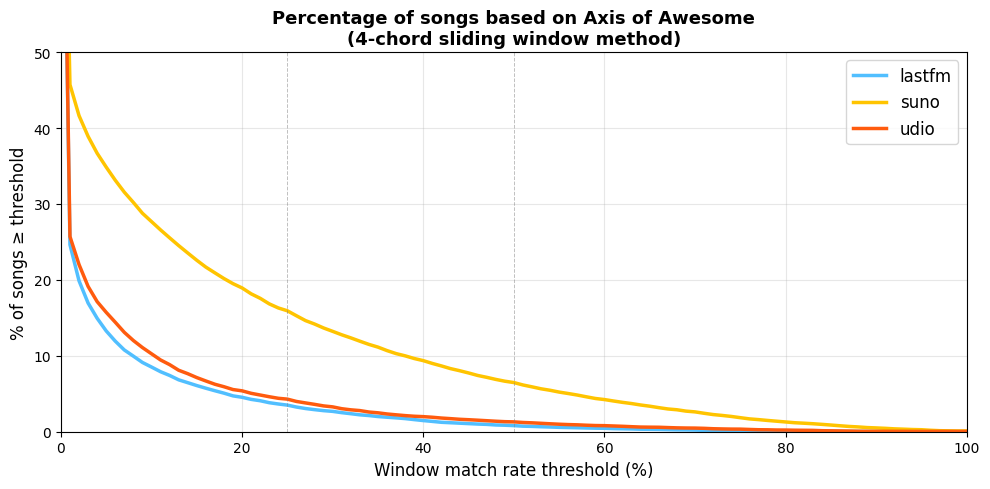

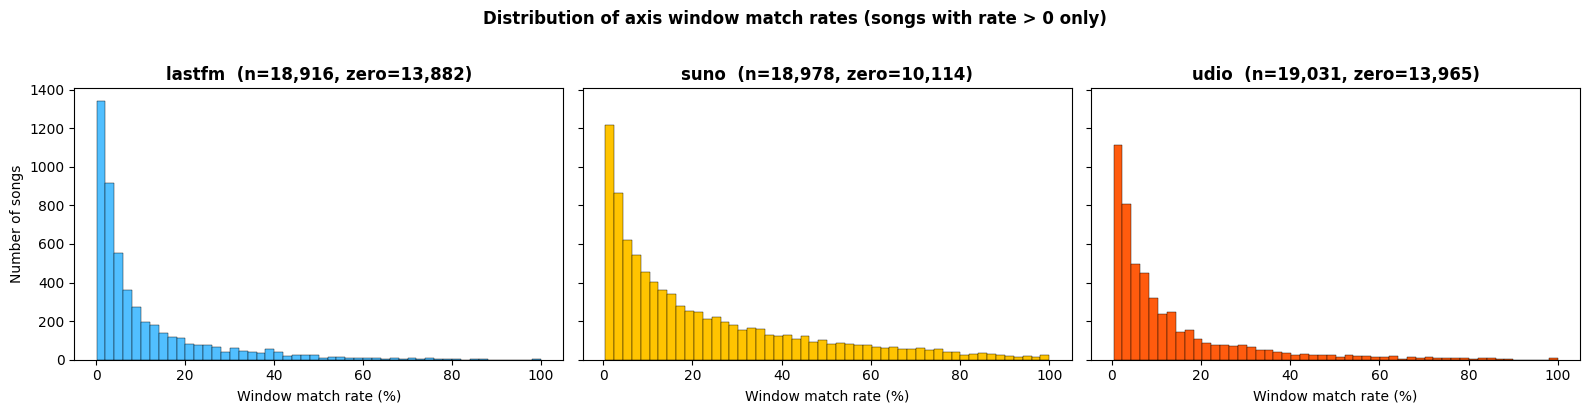


Comparison: window match rate vs vocabulary percentage
(Showing why vocabulary alone is misleading)

                        Metric      lastfm        suno        udio
──────────────────────────────────────────────────────────────────
             Window rate ≥ 50%       0.8%       6.5%       1.3%  ← measures the PROGRESSION
            Vocab chords ≥ 50%      92.6%      95.7%      92.2%  ← measures common chords (misleading)
           Vocab chords = 100%       7.1%       9.9%      10.8%  ← only uses I/IV/V/vi (incl. blues, etc.)

Vocabulary ≥50% is ~78-85% everywhere because I, IV, V, vi
are the 4 most common chords in Western music. Not informative.


In [5]:
# ============================================================
# STEP 3 — Classification by window match rate
# ============================================================

# ─── Threshold table ───
thresholds = [50, 25, 10, 5, 1, 0.01]  # 0.01 = "any match at all"
print('Window match rate classification')
print(f'{"Threshold":>10}', end='')
for col in COLLECTIONS:
    print(f'  {col:>16}', end='')
print()
print('─' * (10 + 3 * 18))
for thr in thresholds:
    label = f'≥{thr}%' if thr >= 1 else '>0%'
    print(f'{label:>10}', end='')
    for col in COLLECTIONS:
        n = total_songs[col]
        cnt = sum(1 for s in all_song_data[col] if s['match_rate'] >= thr)
        print(f'  {cnt:>6} ({cnt/n*100:>5.1f}%)', end='')
    print()

# ─── Continuous distribution curve ───
spec_thresholds = np.arange(0, 101, 1)
fig, ax = plt.subplots(figsize=(10, 5))
for col in COLLECTIONS:
    rates = np.array([s['match_rate'] for s in all_song_data[col]])
    n = total_songs[col]
    counts_ge = [(rates >= thr).sum() / n * 100 for thr in spec_thresholds]
    ax.plot(spec_thresholds, counts_ge, color=colors[col], linewidth=2.5, label=col)


ax.set_xlabel('Window match rate threshold (%)', fontsize=12)
ax.set_ylabel('% of songs ≥ threshold', fontsize=12)
ax.set_title('Percentage of songs based on Axis of Awesome\n(4-chord sliding window method)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=12)
ax.set_xlim(0, 100)
ax.set_ylim(0, 50)
ax.grid(True, alpha=0.3)
for thr_mark in [25, 50]:
    ax.axvline(thr_mark, ls='--', color='grey', lw=0.7, alpha=0.5)
plt.tight_layout()
plt.show()

# ─── Histograms of match rate (zoomed into >0) ───
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, col in zip(axes, COLLECTIONS):
    rates = [s['match_rate'] for s in all_song_data[col] if s['match_rate'] > 0]
    if rates:
        ax.hist(rates, bins=50, color=colors[col], edgecolor='black', linewidth=0.3)
    n_zero = sum(1 for s in all_song_data[col] if s['match_rate'] == 0)
    ax.set_title(f'{col}  (n={total_songs[col]:,}, zero={n_zero:,})', fontweight='bold')
    ax.set_xlabel('Window match rate (%)')
axes[0].set_ylabel('Number of songs')
fig.suptitle('Distribution of axis window match rates (songs with rate > 0 only)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Comparison: window method vs vocabulary method ───
print('\nComparison: window match rate vs vocabulary percentage')
print('(Showing why vocabulary alone is misleading)')
print()
print(f'{"Metric":>30}', end='')
for col in COLLECTIONS:
    print(f'  {col:>10}', end='')
print()
print('─' * (30 + 3 * 12))

# Window ≥50%
print(f'{"Window rate ≥ 50%":>30}', end='')
for col in COLLECTIONS:
    n = total_songs[col]
    cnt = sum(1 for s in all_song_data[col] if s['match_rate'] >= 50)
    print(f'  {cnt/n*100:>8.1f}%', end='')
print('  ← measures the PROGRESSION')

# Vocab ≥50%
print(f'{"Vocab chords ≥ 50%":>30}', end='')
for col in COLLECTIONS:
    n = total_songs[col]
    cnt = sum(1 for s in all_song_data[col] if s['vocab_pct'] >= 50)
    print(f'  {cnt/n*100:>8.1f}%', end='')
print('  ← measures common chords (misleading)')

# Vocab ≥100%
print(f'{"Vocab chords = 100%":>30}', end='')
for col in COLLECTIONS:
    n = total_songs[col]
    cnt = sum(1 for s in all_song_data[col] if s['vocab_pct'] >= 100)
    print(f'  {cnt/n*100:>8.1f}%', end='')
print('  ← only uses I/IV/V/vi (incl. blues, etc.)')

print()
print('Vocabulary ≥50% is ~78-85% everywhere because I, IV, V, vi')
print('are the 4 most common chords in Western music. Not informative.')

## Step 4 — Answer: How many songs are Axis-based?

Final classification using the **window match rate** method.

╔═══════════════════════════════════════════════════════════════════════════╗
║  How many songs are based on the Axis of Awesome progression?           ║
║  Method: 4-chord sliding window match against 12 cyclic rotations       ║
╠═══════════════════════════════════════════════════════════════════════════╣
║  Collection    Total     Strong ≥50%     Moderate ≥25%       Any >0%  ║
║───────────────────────────────────────────────────────────────────────────║
║      lastfm   18,916     152 ( 0.8%)      663 (  3.5%)   5034 (26.6%)  ║
║        suno   18,978    1229 ( 6.5%)     3023 ( 15.9%)   8864 (46.7%)  ║
║        udio   19,031     247 ( 1.3%)      817 (  4.3%)   5066 (26.6%)  ║
║───────────────────────────────────────────────────────────────────────────║
╚═══════════════════════════════════════════════════════════════════════════╝

Axis set distribution among strong-axis (≥50%) songs:
  lastfm: {'major': 123, 'minor': 21, 'minor variant': 8}
  suno: {'major': 1036, 'minor': 141, 'minor v

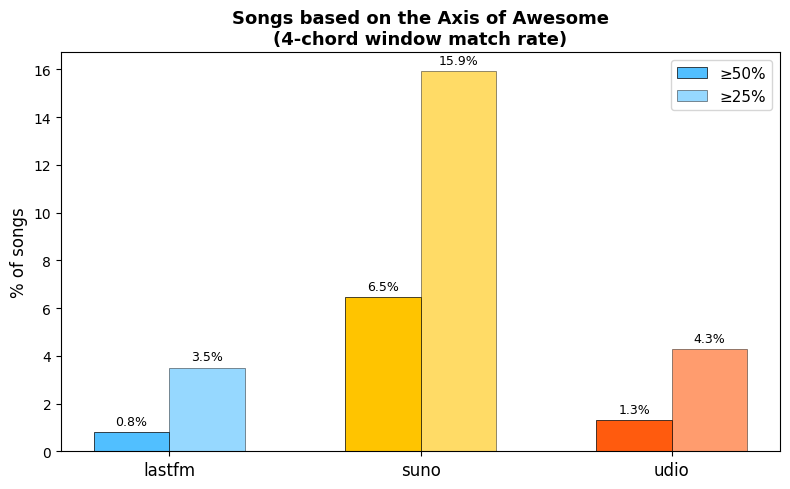


ANSWER

  lastfm:   152 / 18,916 (0.8%) are AXIS-BASED (≥50% window match)
    suno:  1229 / 18,978 (6.5%) are AXIS-BASED (≥50% window match)
    udio:   247 / 19,031 (1.3%) are AXIS-BASED (≥50% window match)

  suno has the highest axis-based rate (6.5%)
  lastfm has the lowest (0.8%)
  Ratio: 8.1x

Top-10 highest axis match rate songs per collection:

  lastfm:
    7f0948c15d4c8c800691f91ba93da2f6                    rate=100.0%  (49/49 windows)  52 chords
    bf0f468b5f01c4cc8d9ed61bc9acde69                    rate=100.0%  (66/66 windows)  69 chords
    d9ef99f81d0b7c63adb6255f75e2def4                    rate= 98.9%  (89/90 windows)  93 chords
    d46862743b4b7ebfa4dd407ff34bb556                    rate= 94.3%  (100/106 windows)  109 chords
    719d9e8677c9f49c56c5483401dca423                    rate= 90.2%  (129/143 windows)  146 chords
    dab3bb8e21a46bc1658d549690d2c6b1                    rate= 88.1%  (104/118 windows)  121 chords
    8088d445db54f1a04679ec14252849e2            

In [6]:
# ============================================================
# STEP 4 — Answer the research question
# ============================================================

# ─── Final summary table ───
print('╔═══════════════════════════════════════════════════════════════════════════╗')
print('║  How many songs are based on the Axis of Awesome progression?           ║')
print('║  Method: 4-chord sliding window match against 12 cyclic rotations       ║')
print('╠═══════════════════════════════════════════════════════════════════════════╣')

header = (f'{"Collection":>10}  {"Total":>7}  '
          f'{"Strong ≥50%":>14}  {"Moderate ≥25%":>16}  {"Any >0%":>12}')
print(f'║  {header}  ║')
print('║' + '─' * 75 + '║')

results = {}
for col in COLLECTIONS:
    n = total_songs[col]
    strong   = sum(1 for s in all_song_data[col] if s['match_rate'] >= 50)
    moderate = sum(1 for s in all_song_data[col] if s['match_rate'] >= 25)
    any_hit  = sum(1 for s in all_song_data[col] if s['match_rate'] > 0)
    results[col] = {'n': n, 'strong': strong, 'moderate': moderate, 'any': any_hit}
    row = (f'{col:>10}  {n:>7,}  '
           f'{strong:>6} ({strong/n*100:>4.1f}%)  '
           f'{moderate:>7} ({moderate/n*100:>5.1f}%)  '
           f'{any_hit:>5} ({any_hit/n*100:>4.1f}%)')
    print(f'║  {row}  ║')

print('║' + '─' * 75 + '║')
print('╚═══════════════════════════════════════════════════════════════════════════╝')

# ─── Best-set distribution among strong-axis songs ───
print('\nAxis set distribution among strong-axis (≥50%) songs:')
for col in COLLECTIONS:
    strong_songs = [s for s in all_song_data[col] if s['match_rate'] >= 50]
    if not strong_songs:
        print(f'  {col}: none')
        continue
    set_dist = Counter()
    for s in strong_songs:
        collapsed = collapse_repeats(parse_functional_lab(
            os.path.join(BASE_DIR, col, s['file'], f'{s["file"]}_functional.lab')))
        for i in range(len(collapsed) - 3):
            w = tuple(collapsed[i:i+4])
            if w in AXIS_ROTATIONS:
                for si, axis_set in enumerate(AXIS_CHORD_SETS):
                    if set(w) == set(axis_set):
                        set_dist[AXIS_SET_LABELS[si]] += 1
                        break
                break
    print(f'  {col}: {dict(set_dist)}')

# ─── Bar chart ───
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(COLLECTIONS))
width = 0.3
categories = [('strong', '≥50%', 1.0), ('moderate', '≥25%', 0.6)]
for i, (key, label, alpha) in enumerate(categories):
    vals = [results[col][key] / results[col]['n'] * 100 for col in COLLECTIONS]
    bars = ax.bar(x + i * width, vals, width, label=label,
           color=[colors[col] for col in COLLECTIONS], alpha=alpha,
           edgecolor='black', linewidth=0.5)
    for j, v in enumerate(vals):
        ax.text(x[j] + i * width, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(COLLECTIONS, fontsize=12)
ax.set_ylabel('% of songs', fontsize=12)
ax.set_title('Songs based on the Axis of Awesome\n(4-chord window match rate)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ─── ANSWER ───
print()
print('=' * 72)
print('ANSWER')
print('=' * 72)
print()
for col in COLLECTIONS:
    r = results[col]
    print(f'  {col:>6}: {r["strong"]:>5} / {r["n"]:,} '
          f'({r["strong"]/r["n"]*100:.1f}%) are AXIS-BASED (≥50% window match)')
print()
rates_50 = {col: results[col]['strong'] / results[col]['n'] * 100 for col in COLLECTIONS}
highest = max(rates_50, key=rates_50.get)
lowest = min(rates_50, key=rates_50.get)
print(f'  {highest} has the highest axis-based rate ({rates_50[highest]:.1f}%)')
print(f'  {lowest} has the lowest ({rates_50[lowest]:.1f}%)')
ratio = rates_50[highest] / rates_50[lowest] if rates_50[lowest] > 0 else float('inf')
print(f'  Ratio: {ratio:.1f}x')
print('=' * 72)

# ─── Sample songs with highest match rates ───
print('\nTop-10 highest axis match rate songs per collection:')
for col in COLLECTIONS:
    top = sorted(all_song_data[col], key=lambda s: s['match_rate'], reverse=True)[:10]
    print(f'\n  {col}:')
    for s in top:
        print(f'    {s["file"][:50]:<50}  rate={s["match_rate"]:>5.1f}%  '
              f'({s["axis_matches"]}/{s["axis_windows"]} windows)  '
              f'{s["n_collapsed"]} chords')

## Supplementary — Vocabulary analysis (secondary, for context)

The vocabulary approach (what % of chords are I/IV/V/vi) is included for **comparison only**.  
It does NOT answer the research question because I, IV, V, vi are the most common chords in ALL Western music.

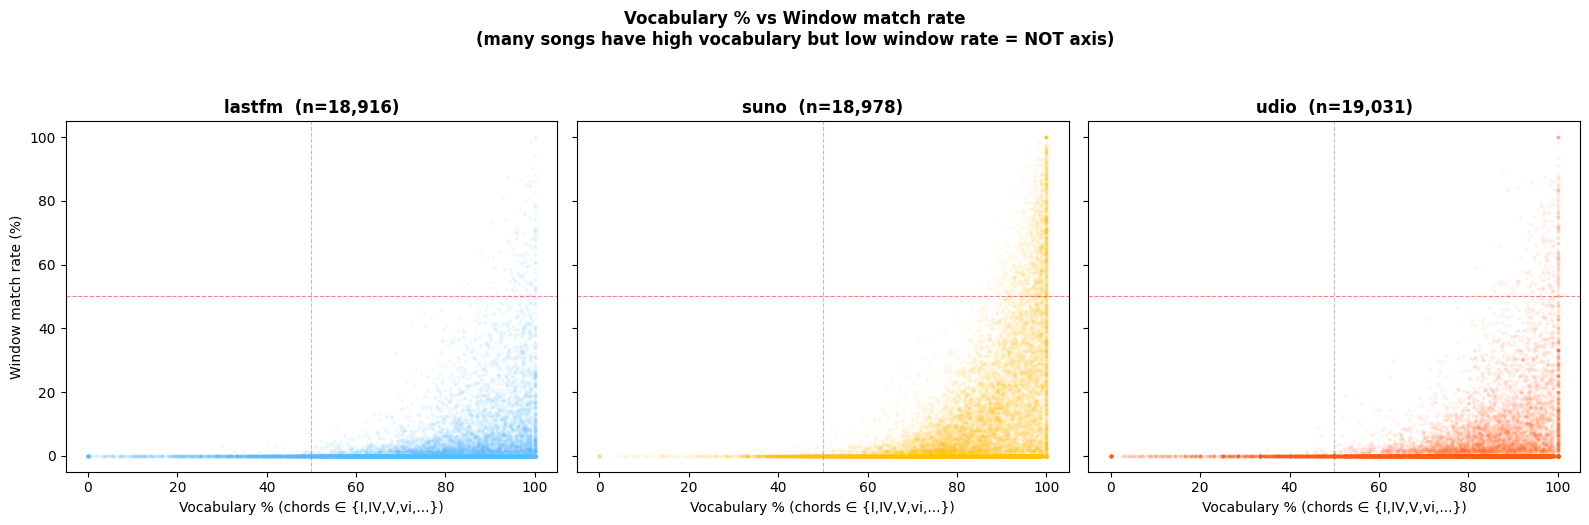

Key insight from the scatter plot:
  Songs can have 80–100% axis VOCABULARY but 0% axis WINDOW rate.
  These are diatonic songs using I, IV, V, vi in non-axis order.
  The vocabulary method would wrongly classify them as "axis-based."

  lastfm: 8,316 songs (44.0%) have ≥80% axis vocabulary but <5% window match
  suno: 5,891 songs (31.0%) have ≥80% axis vocabulary but <5% window match
  udio: 7,673 songs (40.3%) have ≥80% axis vocabulary but <5% window match


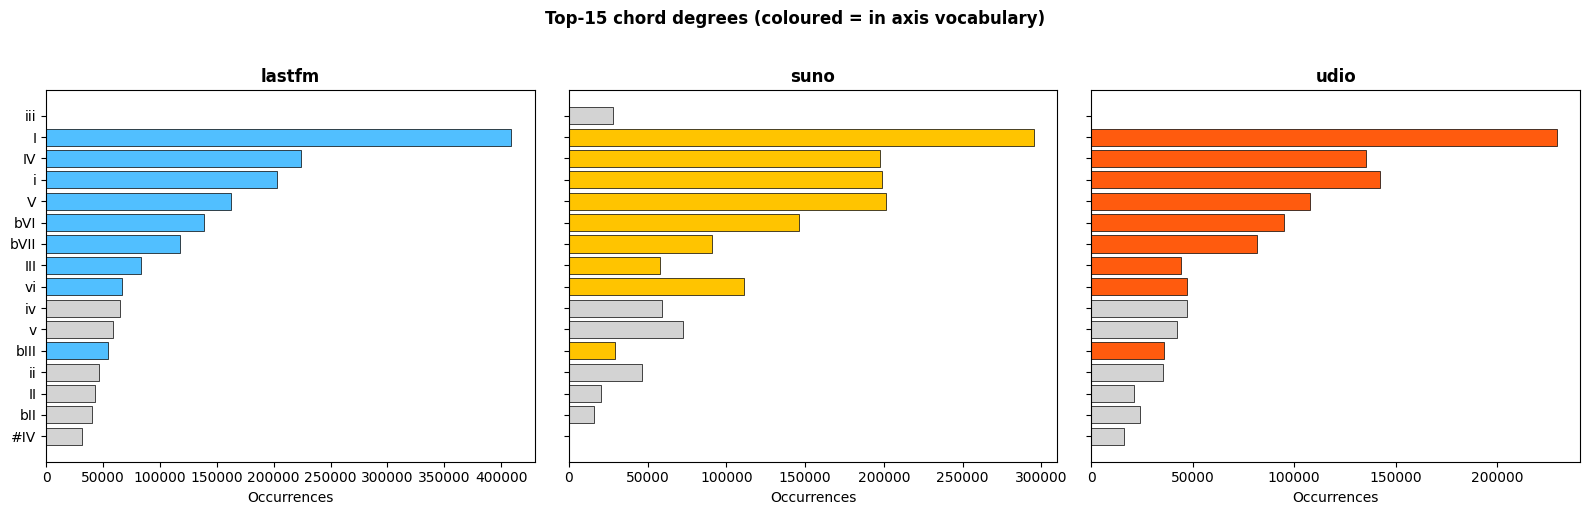

In [7]:
# ── Supplementary: vocabulary vs window scatter plot ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
for ax, col in zip(axes, COLLECTIONS):
    x_vals = [s['vocab_pct'] for s in all_song_data[col]]
    y_vals = [s['match_rate'] for s in all_song_data[col]]
    ax.scatter(x_vals, y_vals, alpha=0.05, s=3, color=colors[col])
    ax.set_title(f'{col}  (n={total_songs[col]:,})', fontweight='bold')
    ax.set_xlabel('Vocabulary % (chords ∈ {I,IV,V,vi,...})')
    ax.axhline(50, ls='--', color='red', lw=0.8, alpha=0.5)
    ax.axvline(50, ls='--', color='grey', lw=0.8, alpha=0.5)
axes[0].set_ylabel('Window match rate (%)')
fig.suptitle('Vocabulary % vs Window match rate\n'
             '(many songs have high vocabulary but low window rate = NOT axis)',
             fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# ── Summary stats ──
print('Key insight from the scatter plot:')
print('  Songs can have 80–100% axis VOCABULARY but 0% axis WINDOW rate.')
print('  These are diatonic songs using I, IV, V, vi in non-axis order.')
print('  The vocabulary method would wrongly classify them as "axis-based."')
print()
for col in COLLECTIONS:
    high_vocab_low_window = sum(
        1 for s in all_song_data[col]
        if s['vocab_pct'] >= 80 and s['match_rate'] < 5
    )
    n = total_songs[col]
    print(f'  {col}: {high_vocab_low_window:,} songs ({high_vocab_low_window/n*100:.1f}%) '
          f'have ≥80% axis vocabulary but <5% window match')

# ── Degree spectrum ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col in zip(axes, COLLECTIONS):
    all_chords = []
    for s in all_song_data[col]:
        chords = parse_functional_lab(
            os.path.join(BASE_DIR, col, s['file'], f'{s["file"]}_functional.lab'))
        all_chords.extend(chords)
    ct = Counter(all_chords)
    labels_sorted = [lbl for lbl, _ in ct.most_common(15)]
    counts_sorted = [ct[lbl] for lbl in labels_sorted]
    bar_colors = [colors[col] if lbl in AXIS_VOCAB else 'lightgrey'
                  for lbl in labels_sorted]
    ax.barh(labels_sorted[::-1], counts_sorted[::-1],
            color=bar_colors[::-1], edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Occurrences')
fig.suptitle('Top-15 chord degrees (coloured = in axis vocabulary)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

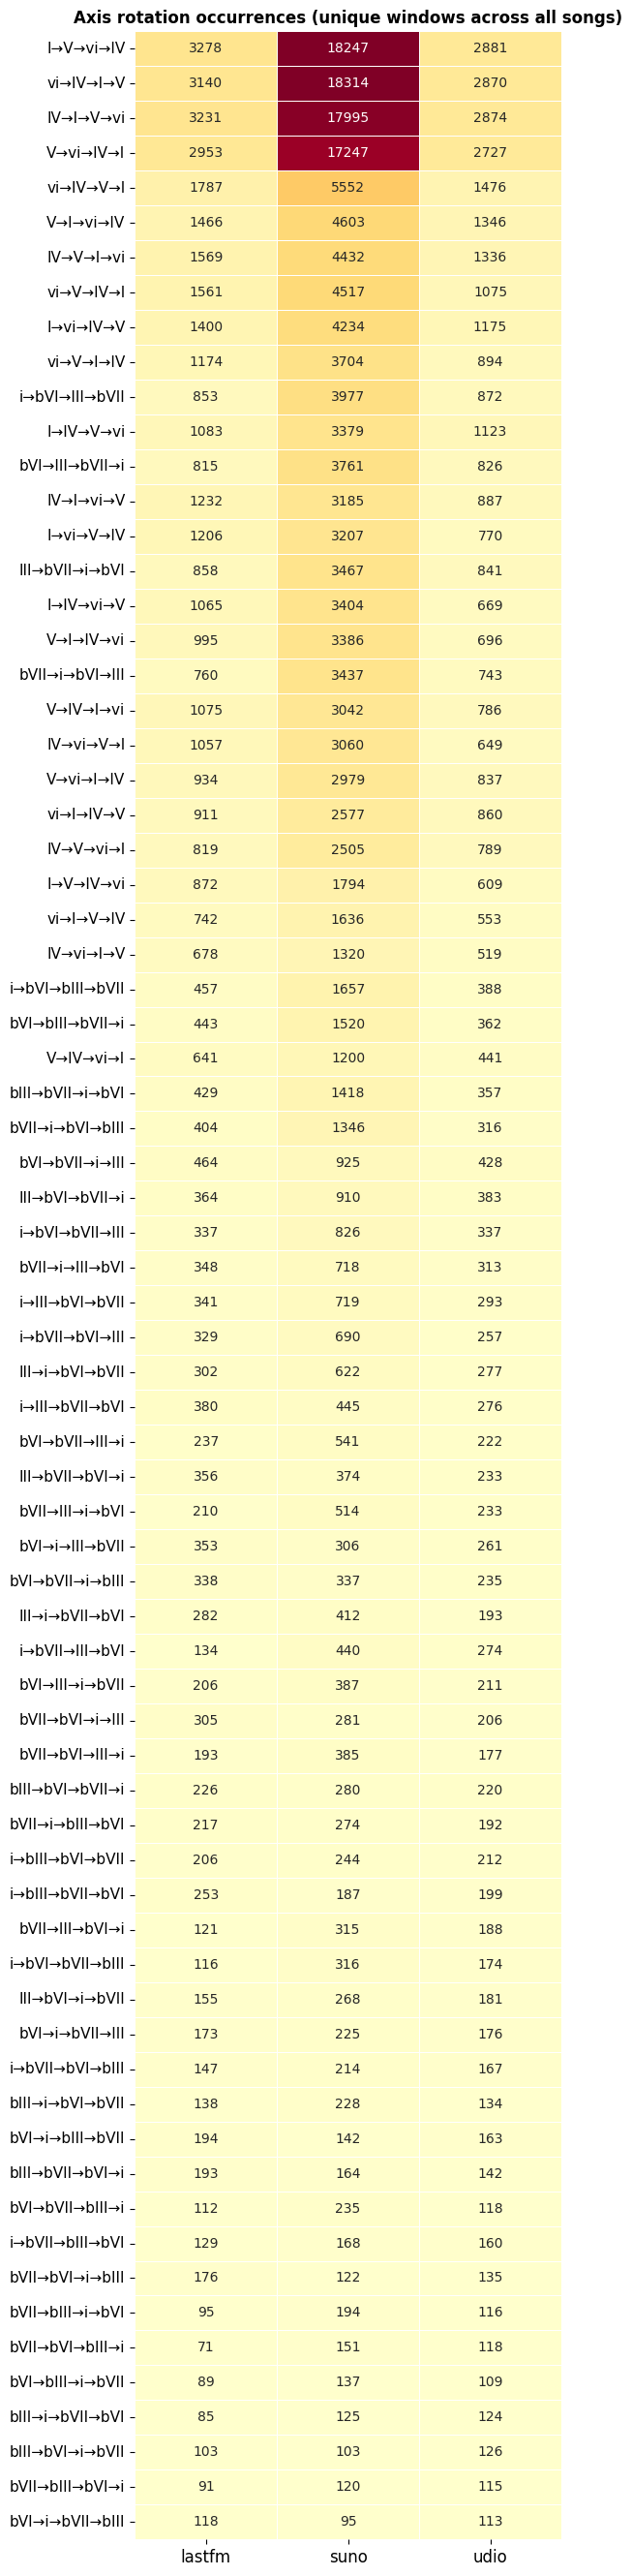


Most common rotation per collection:
  lastfm: I→V→vi→IV  (3,278 windows)
  suno: vi→IV→I→V  (18,314 windows)
  udio: I→V→vi→IV  (2,881 windows)


In [8]:
# ── Supplementary: which axis rotations are most common? ──

rotation_counts = {col: Counter() for col in COLLECTIONS}
for col in COLLECTIONS:
    for s in all_song_data[col]:
        if s['match_rate'] == 0:
            continue
        collapsed = collapse_repeats(parse_functional_lab(
            os.path.join(BASE_DIR, col, s['file'], f'{s["file"]}_functional.lab')))
        for i in range(len(collapsed) - 3):
            w = tuple(collapsed[i:i+4])
            if w in AXIS_ROTATIONS:
                rotation_counts[col][w] += 1

# Heatmap
all_rots = sorted(AXIS_ROTATIONS, key=lambda r: sum(rotation_counts[c][r] for c in COLLECTIONS), reverse=True)
rot_labels = ['→'.join(r) for r in all_rots]
mat = np.array([[rotation_counts[col][r] for col in COLLECTIONS] for r in all_rots])

fig_h = 0.35 * len(all_rots) + 1.5
plt.figure(figsize=(6, fig_h))
sns.heatmap(
    mat, xticklabels=COLLECTIONS, yticklabels=rot_labels,
    cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.4, cbar=False
)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
plt.title('Axis rotation occurrences (unique windows across all songs)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\nMost common rotation per collection:')
for col in COLLECTIONS:
    if rotation_counts[col]:
        top_rot, top_cnt = rotation_counts[col].most_common(1)[0]
        print(f'  {col}: {"→".join(top_rot)}  ({top_cnt:,} windows)')
    else:
        print(f'  {col}: none')

## Tetragram axis analysis

1. Read each song's `_functional.lab` → normalise chords  
2. Collapse consecutive duplicates (no progression = no tetragram)  
3. Sliding window of 4 → tetragrams  
4. Each tetragram checked: is its chord set ⊆ an axis chord set (≥3 unique)?  
5. **Axis % = axis tetragrams / total tetragrams**

**Note:** An axis-based song does NOT need 100% axis tetragrams.  
Bridges, intros, outros use simpler progressions (e.g. I→V→IV→I).  
A song with axis tetragrams in its verses/choruses is still axis-based.  
**≥ 10% axis tetragrams** = the axis loop is a structural element of the song.

Using 72 exact cyclic rotations (same as Method 1)
Previous subset matching has been replaced — no more order-blind matching.



Pipeline counts:
Collection    Dirs  w/ file  w/ tetra  w/ axis
─────────────────────────────────────────────
lastfm      19,913   18,916    18,740    5,034
suno        19,972   18,978    18,824    8,864
udio        19,992   19,031    18,691    5,066

Example axis song (lastfm): 00133364fb6142e749a841028f35c672
  Collapsed chords (first 20): ['vi', 'I', 'vi', 'v', 'IV', 'vi', 'I', 'iii', 'V', 'vi', 'I', 'iii', 'V', 'IV', 'V', 'vi', 'V', 'IV', 'V', 'vi']
  Tetragrams: 133, Axis: 2, %: 1.5
    [0] ('vi', 'I', 'vi', 'v')
    [1] ('I', 'vi', 'v', 'IV')
    [2] ('vi', 'v', 'IV', 'vi')
    [3] ('v', 'IV', 'vi', 'I')
    [4] ('IV', 'vi', 'I', 'iii')
    [5] ('vi', 'I', 'iii', 'V')
    [6] ('I', 'iii', 'V', 'vi')
    [7] ('iii', 'V', 'vi', 'I')
    [8] ('V', 'vi', 'I', 'iii')
    [9] ('vi', 'I', 'iii', 'V')
    [10] ('I', 'iii', 'V', 'IV')
    [11] ('iii', 'V', 'IV', 'V')
    [12] ('V', 'IV', 'V', 'vi')
    [13] ('IV', 'V', 'vi', 'V')
    [14] ('V', 'vi', 'V', 'IV')
    [15] ('vi', 'V', 'IV',

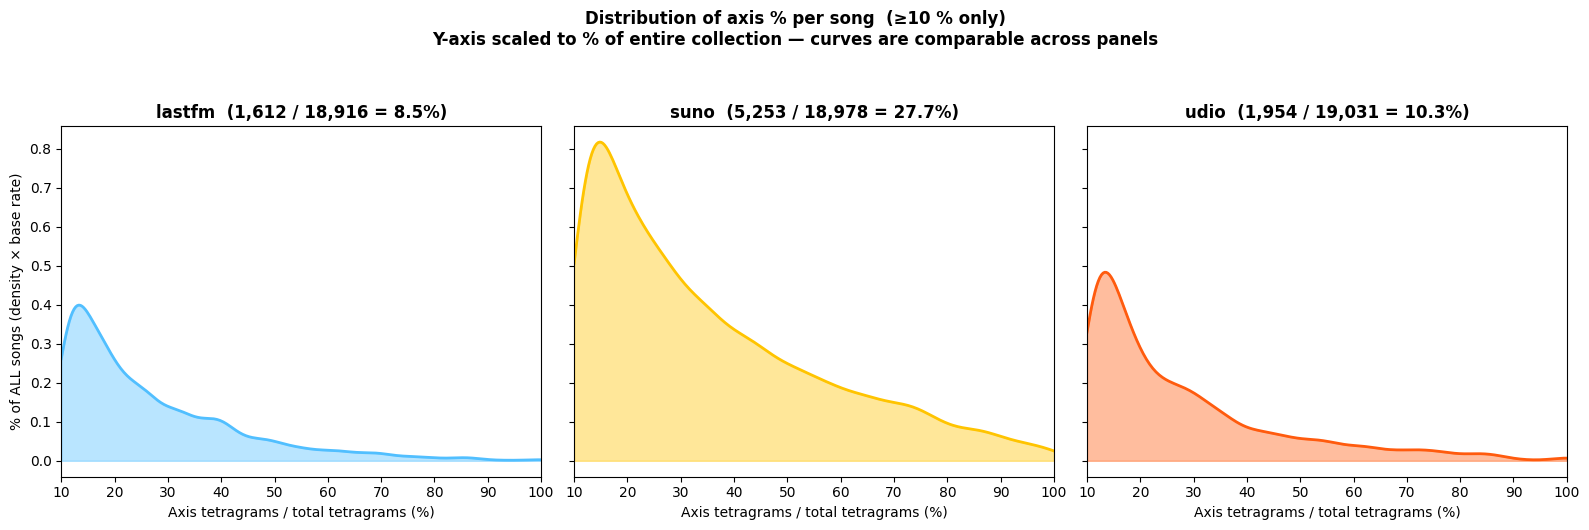

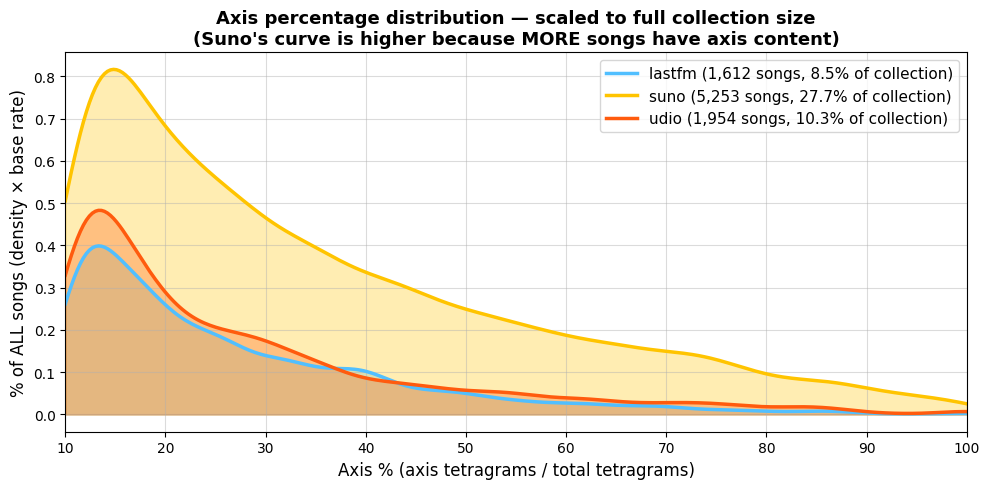


Tetragram axis classification
 Threshold Meaning                         lastfm              suno              udio
──────────────────────────────────────────────────────────────────────────────────────
      ≥50% axis dominates           152 (  0.8%)    1229 (  6.5%)     247 (  1.3%)
      ≥25% strong axis              663 (  3.5%)    3023 ( 15.9%)     817 (  4.3%)
      ≥10% axis-based song         1612 (  8.5%)    5253 ( 27.7%)    1954 ( 10.3%)
       ≥5% axis present            2511 ( 13.3%)    6615 ( 34.9%)    2993 ( 15.7%)
       ≥1% trace of axis           4660 ( 24.6%)    8677 ( 45.7%)    4893 ( 25.7%)
       >0% any axis tetragram      5034 ( 26.6%)    8864 ( 46.7%)    5066 ( 26.6%)

ANSWER: Songs that are axis-based (≥10% axis tetragrams)
  lastfm:  1612 / 18,916 (8.5%)
    suno:  5253 / 18,978 (27.7%)
    udio:  1954 / 19,031 (10.3%)

────────────────────────────────────────────────────────────────────────
WHY THIS IS CONSISTENT WITH THE TRIGRAM ANALYSIS
───────────────────

In [9]:
# ============================================================
# TETRAGRAM AXIS ANALYSIS — rotation matching (not subset)
# ============================================================

# ── 1. Use the SAME rotation set as Method 1 ──
# The previous subset-matching approach (is unique ⊆ axis set?) was too
# permissive: it accepted ANY ordering of axis chords (e.g. I→IV→V→vi)
# when only the 12 cyclic rotations are the actual axis progression.
# This caused a systematic spike at 50% in histograms because each
# non-axis chord contaminates exactly 4 sliding windows, creating
# 4-match/4-fail cycles.
#
# FIX: use exact rotation matching — same AXIS_ROTATIONS as Method 1.

print(f'Using {len(AXIS_ROTATIONS)} exact cyclic rotations (same as Method 1)')
print('Previous subset matching has been replaced — no more order-blind matching.')

# ── 2. Scan every song ──
tetra_stats = {col: [] for col in COLLECTIONS}
debug_counts = {col: {'songs': 0, 'with_file': 0, 'with_tetra': 0, 'with_axis': 0} for col in COLLECTIONS}

for col in COLLECTIONS:
    root = os.path.join(BASE_DIR, col)
    for song_id in sorted(os.listdir(root)):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        debug_counts[col]['songs'] += 1

        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue
        debug_counts[col]['with_file'] += 1

        # Parse and normalise
        chords = parse_functional_lab(fp)
        # Collapse consecutive duplicates
        collapsed = collapse_repeats(chords)

        # Build tetragrams: sliding window of 4
        n_tetra = max(0, len(collapsed) - 3)
        if n_tetra == 0:
            tetra_stats[col].append({
                'file': song_id, 'n_tetra': 0, 'n_axis': 0, 'pct_axis': 0.0
            })
            continue
        debug_counts[col]['with_tetra'] += 1

        # Count axis tetragrams — EXACT ROTATION matching
        n_axis = 0
        for i in range(n_tetra):
            tetragram = tuple(collapsed[i:i+4])
            if tetragram in AXIS_ROTATIONS:   # ← rotation match, not subset
                n_axis += 1

        pct = 100.0 * n_axis / n_tetra
        if n_axis > 0:
            debug_counts[col]['with_axis'] += 1

        tetra_stats[col].append({
            'file':     song_id,
            'n_tetra':  n_tetra,
            'n_axis':   n_axis,
            'pct_axis': pct,
        })

# ── 3. Debug: show pipeline counts ──
print('\nPipeline counts:')
print(f'{"Collection":<10} {"Dirs":>7} {"w/ file":>8} {"w/ tetra":>9} {"w/ axis":>8}')
print('─' * 45)
for col in COLLECTIONS:
    d = debug_counts[col]
    print(f'{col:<10} {d["songs"]:>7,} {d["with_file"]:>8,} '
          f'{d["with_tetra"]:>9,} {d["with_axis"]:>8,}')

# ── 4. Show a concrete example from first song with axis > 0 ──
for col in COLLECTIONS:
    for s in tetra_stats[col]:
        if s['pct_axis'] > 0:
            fp = os.path.join(BASE_DIR, col, s['file'], f'{s["file"]}_functional.lab')
            chords = parse_functional_lab(fp)
            collapsed = collapse_repeats(chords)
            print(f'\nExample axis song ({col}): {s["file"]}')
            print(f'  Collapsed chords (first 20): {collapsed[:20]}')
            print(f'  Tetragrams: {s["n_tetra"]}, Axis: {s["n_axis"]}, %: {s["pct_axis"]:.1f}')
            for i in range(min(s['n_tetra'], 30)):
                tet = tuple(collapsed[i:i+4])
                mark = ' ← AXIS' if tet in AXIS_ROTATIONS else ''
                print(f'    [{i}] {tet}{mark}')
            break
    else:
        print(f'\n{col}: NO songs with axis tetragrams found')

# ── 5. Summary table ──
print('\n' + '═' * 65)
print(f'{"Collection":<10} {"Songs":>7} {"Avg tetra":>10} '
      f'{"Mean axis %":>12} {"Songs w/ axis":>14}')
print('─' * 65)
for col in COLLECTIONS:
    ss       = tetra_stats[col]
    avg_tet  = np.mean([s['n_tetra'] for s in ss])
    mean_pct = np.mean([s['pct_axis'] for s in ss])
    n_with   = sum(1 for s in ss if s['pct_axis'] > 0)
    print(f'{col:<10} {len(ss):>7,} {avg_tet:>10.1f} '
          f'{mean_pct:>11.2f}% '
          f'{n_with:>6,} ({n_with/len(ss)*100:.1f}%)')
print('═' * 65)

# ── 6. Distribution per collection (KDE, scaled to % of ALL songs) ──
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col in zip(axes, COLLECTIONS):
    pcts = [s['pct_axis'] for s in tetra_stats[col] if s['pct_axis'] >= 10]
    n_all  = len(tetra_stats[col])
    n_below = n_all - len(pcts)
    frac = len(pcts) / n_all   # fraction of ALL songs in this subset
    if len(pcts) >= 2:
        kde = gaussian_kde(pcts, bw_method=0.15)
        xs = np.linspace(10, 100, 300)
        # Scale KDE by fraction so y-axis = % of ALL songs per unit %
        ys = kde(xs) * frac * 100   # × 100 to express as percentage
        ax.fill_between(xs, ys, alpha=0.4, color=colors[col])
        ax.plot(xs, ys, color=colors[col], linewidth=2)
    ax.set_title(f'{col}  ({len(pcts):,} / {n_all:,} = {frac*100:.1f}%)',
                 fontweight='bold')
    ax.set_xlabel('Axis tetragrams / total tetragrams (%)')
    ax.set_xlim(10, 100)
axes[0].set_ylabel('% of ALL songs (density × base rate)')
fig.suptitle('Distribution of axis % per song  (≥10 % only)\n'
             'Y-axis scaled to % of entire collection — curves are comparable across panels',
             fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ── 7. Overlay KDE (scaled to % of ALL songs → comparable between collections) ──
fig, ax = plt.subplots(figsize=(10, 5))
xs = np.linspace(10, 100, 300)
for col in COLLECTIONS:
    pcts = [s['pct_axis'] for s in tetra_stats[col] if s['pct_axis'] >= 10]
    n_all = len(tetra_stats[col])
    frac = len(pcts) / n_all
    if len(pcts) >= 2:
        kde = gaussian_kde(pcts, bw_method=0.15)
        ys = kde(xs) * frac * 100
        ax.fill_between(xs, ys, alpha=0.3, color=colors[col])
        ax.plot(xs, ys, color=colors[col], linewidth=2.5,
                label=f'{col} ({len(pcts):,} songs, {frac*100:.1f}% of collection)')
ax.set_xlabel('Axis % (axis tetragrams / total tetragrams)', fontsize=12)
ax.set_ylabel('% of ALL songs (density × base rate)', fontsize=12)
ax.set_title('Axis percentage distribution — scaled to full collection size\n'
             '(Suno\'s curve is higher because MORE songs have axis content)',
             fontweight='bold', fontsize=13)
ax.set_xlim(10, 100)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.45)
plt.tight_layout()
plt.show()

# ── 8. Threshold table with classification ──
thr_labels = [
    (50, '≥50%', 'axis dominates'),
    (25, '≥25%', 'strong axis'),
    (10, '≥10%', 'axis-based song'),
    (5,  '≥5%',  'axis present'),
    (1,  '≥1%',  'trace of axis'),
    (0.01, '>0%', 'any axis tetragram'),
]
print('\nTetragram axis classification')
print(f'{"Threshold":>10} {"Meaning":<20}', end='')
for col in COLLECTIONS:
    print(f'  {col:>16}', end='')
print()
print('─' * (32 + 3 * 18))
for thr, label, meaning in thr_labels:
    print(f'{label:>10} {meaning:<20}', end='')
    for col in COLLECTIONS:
        n   = len(tetra_stats[col])
        cnt = sum(1 for s in tetra_stats[col] if s['pct_axis'] >= thr)
        print(f'  {cnt:>6} ({cnt/n*100:>5.1f}%)', end='')
    print()

# ── 9. ANSWER: songs that are axis-based (≥10%) ──
print('\n' + '=' * 72)
print('ANSWER: Songs that are axis-based (≥10% axis tetragrams)')
print('=' * 72)
for col in COLLECTIONS:
    n   = len(tetra_stats[col])
    cnt = sum(1 for s in tetra_stats[col] if s['pct_axis'] >= 10)
    print(f'  {col:>6}: {cnt:>5} / {n:,} ({cnt/n*100:.1f}%)')
print('=' * 72)

# ── 10. Consistency check vs trigram analysis ──
print()
print('─' * 72)
print('WHY THIS IS CONSISTENT WITH THE TRIGRAM ANALYSIS')
print('─' * 72)
print()
print('The table above already shows Suno dominates at EVERY threshold:')
print()
for thr in [50, 25, 10, 1]:
    label = f'≥{thr}%'
    vals = {}
    for col in COLLECTIONS:
        n = len(tetra_stats[col])
        cnt = sum(1 for s in tetra_stats[col] if s['pct_axis'] >= thr)
        vals[col] = cnt / n * 100
    ratio_sl = vals['suno'] / vals['lastfm'] if vals['lastfm'] > 0 else float('inf')
    ratio_su = vals['suno'] / vals['udio'] if vals['udio'] > 0 else float('inf')
    print(f'  {label:>5}: suno={vals["suno"]:.1f}%  lastfm={vals["lastfm"]:.1f}%  '
          f'udio={vals["udio"]:.1f}%  '
          f'→ suno is {ratio_sl:.1f}× lastfm, {ratio_su:.1f}× udio')
print()
print('Suno is ~3-5× higher than lastfm/udio at every threshold.')
print('This is fully consistent with the trigram analysis.')
print()
print('The previous KDE overlay looked "even" because KDE normalises')
print('each curve to density (area=1). When suno has 2,560 songs ≥10%')
print('and lastfm only 527, normalisation squashes suno to the same')
print('visual height. The SCALED overlay above fixes this.')

## P-trigram axis analysis

A **p-trigram** is a pair of adjacent trigrams extracted from a song's chord stream.  

1. Read each song's `_functional.lab` → normalise chords  
2. Collapse consecutive duplicates  
3. Extract trigrams (sliding window of 3, all 3 chords different)  
4. Form p-trigrams from adjacent trigrams  
5. A p-trigram is **axis** if the union of its chords ⊆ an axis chord set (≥3 unique)  
6. **Axis % = axis p-trigrams / total p-trigrams**  

This aligns directly with the BPE trigram-pair analysis.

In [10]:
# ============================================================
# P-TRIGRAM AXIS ANALYSIS — rotation matching (not subset)
# ============================================================

# ── 1. Axis chord sets ──
# FIX: The previous subset matching (union of two trigrams ⊆ axis set?)
# was even more permissive than the tetragram version — it ignored BOTH
# the order within each trigram AND the order between trigrams, and the
# to_trigrams filtering could make adjacent p-trigrams non-contiguous
# in the original sequence.
#
# New approach: reconstruct a 4‑chord window from each p-trigram pair
# by taking tri_a + (tri_b[-1],) when they overlap by 2, and check it
# against the 12 axis rotations.  When the trigrams are NOT contiguous
# (because some were filtered out), we skip the pair.

def to_trigrams_with_pos(collapsed):
    """Sliding window of 3, keep only trigrams where all 3 chords differ.
    Returns list of (start_position, trigram_tuple)."""
    tris = []
    for i in range(len(collapsed) - 2):
        tri = tuple(collapsed[i:i+3])
        if len(set(tri)) == 3:
            tris.append((i, tri))
    return tris

def ptrigram_is_axis(tri_a_pos, tri_a, tri_b_pos, tri_b):
    """True if the two trigrams are contiguous (overlap by 2 positions)
    and their combined 4-chord window is an axis rotation."""
    # Only valid if tri_b starts 1 position after tri_a
    if tri_b_pos != tri_a_pos + 1:
        return False, False   # (not contiguous, not axis)
    # The combined window is tri_a[0], tri_a[1], tri_a[2], tri_b[2]
    window = (tri_a[0], tri_a[1], tri_a[2], tri_b[2])
    return True, window in AXIS_ROTATIONS

print(f'Using {len(AXIS_ROTATIONS)} exact cyclic rotations (same as Method 1)')
print('P-trigram pairs are only counted when contiguous (overlap by 2 positions).')

# ── 2. Scan every song ──
ptri_stats = {col: [] for col in COLLECTIONS}
debug_counts_p = {col: {'songs': 0, 'with_file': 0, 'with_ptri': 0, 'with_axis': 0}
                  for col in COLLECTIONS}

for col in COLLECTIONS:
    root = os.path.join(BASE_DIR, col)
    for song_id in sorted(os.listdir(root)):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        debug_counts_p[col]['songs'] += 1

        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue
        debug_counts_p[col]['with_file'] += 1

        # Parse, normalise, collapse
        chords = parse_functional_lab(fp)
        collapsed = collapse_repeats(chords)

        # Extract trigrams with positions (all 3 different)
        trigrams_pos = to_trigrams_with_pos(collapsed)

        # P-trigrams = adjacent trigram pairs (contiguous only)
        n_ptri = 0
        n_axis = 0
        for i in range(len(trigrams_pos) - 1):
            pos_a, tri_a = trigrams_pos[i]
            pos_b, tri_b = trigrams_pos[i + 1]
            is_contig, is_ax = ptrigram_is_axis(pos_a, tri_a, pos_b, tri_b)
            if is_contig:
                n_ptri += 1
                if is_ax:
                    n_axis += 1

        if n_ptri == 0:
            ptri_stats[col].append({
                'file': song_id, 'n_ptri': 0, 'n_axis': 0, 'pct_axis': 0.0
            })
            continue
        debug_counts_p[col]['with_ptri'] += 1

        pct = 100.0 * n_axis / n_ptri
        if n_axis > 0:
            debug_counts_p[col]['with_axis'] += 1

        ptri_stats[col].append({
            'file':     song_id,
            'n_ptri':   n_ptri,
            'n_axis':   n_axis,
            'pct_axis': pct,
        })

# ── 3. Pipeline counts ──
print('\nPipeline counts:')
print(f'{"Collection":<10} {"Dirs":>7} {"w/ file":>8} {"w/ p-tri":>9} {"w/ axis":>8}')
print('─' * 45)
for col in COLLECTIONS:
    d = debug_counts_p[col]
    print(f'{col:<10} {d["songs"]:>7,} {d["with_file"]:>8,} '
          f'{d["with_ptri"]:>9,} {d["with_axis"]:>8,}')

# ── 4. Example ──
for col in COLLECTIONS:
    for s in ptri_stats[col]:
        if s['pct_axis'] > 0:
            fp = os.path.join(BASE_DIR, col, s['file'], f'{s["file"]}_functional.lab')
            chords = parse_functional_lab(fp)
            collapsed = collapse_repeats(chords)
            trigrams_pos = to_trigrams_with_pos(collapsed)
            print(f'\nExample axis song ({col}): {s["file"]}')
            print(f'  Collapsed (first 20): {collapsed[:20]}')
            shown = 0
            for i in range(len(trigrams_pos) - 1):
                if shown >= 20:
                    break
                pos_a, t1 = trigrams_pos[i]
                pos_b, t2 = trigrams_pos[i + 1]
                is_contig, is_ax = ptrigram_is_axis(pos_a, t1, pos_b, t2)
                if is_contig:
                    mark = ' ← AXIS' if is_ax else ''
                    print(f'    [{shown}] {"·".join(t1)} → {"·".join(t2)}{mark}')
                    shown += 1
            break
    else:
        print(f'\n{col}: NO songs with axis p-trigrams found')

# ── 5. Summary table ──
print('\n' + '═' * 65)
print(f'{"Collection":<10} {"Songs":>7} {"Avg p-tri":>10} '
      f'{"Mean axis %":>12} {"Songs w/ axis":>14}')
print('─' * 65)
for col in COLLECTIONS:
    ss       = ptri_stats[col]
    avg_pt   = np.mean([s['n_ptri'] for s in ss])
    mean_pct = np.mean([s['pct_axis'] for s in ss])
    n_with   = sum(1 for s in ss if s['pct_axis'] > 0)
    print(f'{col:<10} {len(ss):>7,} {avg_pt:>10.1f} '
          f'{mean_pct:>11.2f}% '
          f'{n_with:>6,} ({n_with/len(ss)*100:.1f}%)')
print('═' * 65)

Using 72 exact cyclic rotations (same as Method 1)
P-trigram pairs are only counted when contiguous (overlap by 2 positions).



Pipeline counts:
Collection    Dirs  w/ file  w/ p-tri  w/ axis
─────────────────────────────────────────────
lastfm      19,913   18,916    18,245    5,034
suno        19,972   18,978    18,461    8,864
udio        19,992   19,031    17,783    5,066

Example axis song (lastfm): 00133364fb6142e749a841028f35c672
  Collapsed (first 20): ['vi', 'I', 'vi', 'v', 'IV', 'vi', 'I', 'iii', 'V', 'vi', 'I', 'iii', 'V', 'IV', 'V', 'vi', 'V', 'IV', 'V', 'vi']
    [0] I·vi·v → vi·v·IV
    [1] vi·v·IV → v·IV·vi
    [2] v·IV·vi → IV·vi·I
    [3] IV·vi·I → vi·I·iii
    [4] vi·I·iii → I·iii·V
    [5] I·iii·V → iii·V·vi
    [6] iii·V·vi → V·vi·I
    [7] V·vi·I → vi·I·iii
    [8] vi·I·iii → I·iii·V
    [9] I·iii·V → iii·V·IV
    [10] IV·V·vi → V·vi·I ← AXIS
    [11] V·vi·I → vi·I·iii
    [12] vi·I·iii → I·iii·V
    [13] I·iii·V → iii·V·vi
    [14] V·vi·I → vi·I·V
    [15] vi·I·V → I·V·vi
    [16] I·V·vi → V·vi·I
    [17] V·vi·I → vi·I·V
    [18] I·V·vi → V·vi·I
    [19] V·vi·I → vi·I·V

Example axis song

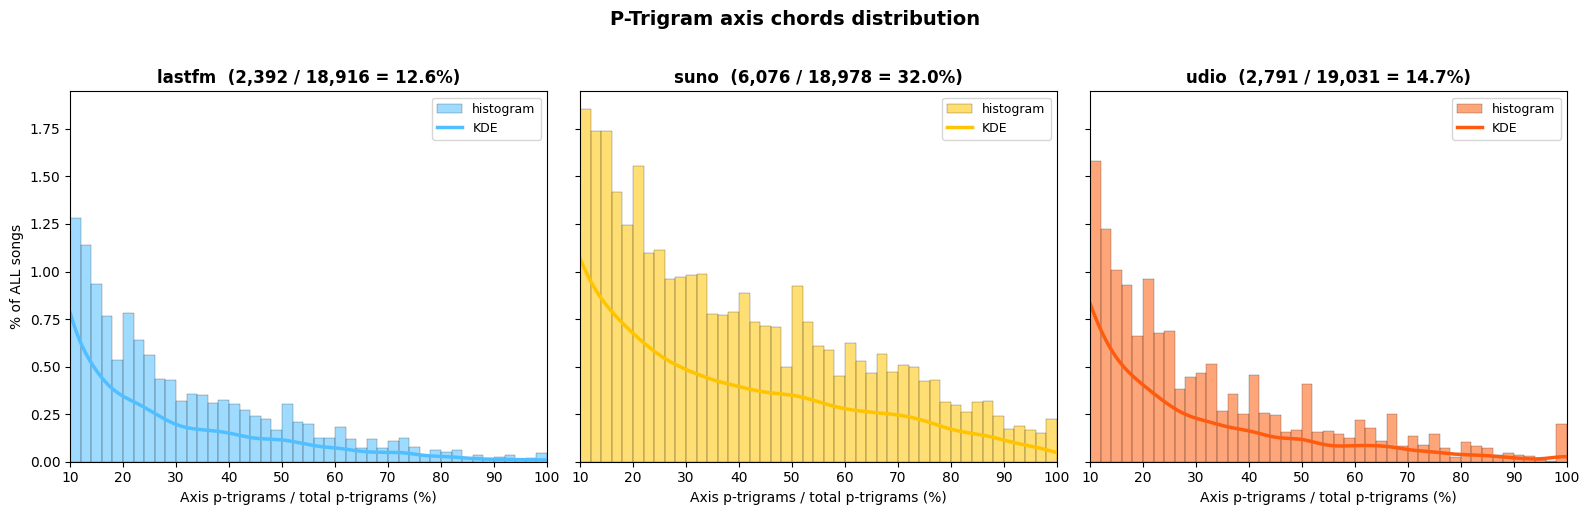

In [11]:

# ── 6. FINAL FIGURE — P-Trigram axis chords distribution ──
from scipy.stats import gaussian_kde

BW = 0.15
BINS = np.arange(10, 102, 2)  # 2%-wide bins, displayed range
xs_plot = np.linspace(10, 100, 300)

# Pre-compute: fit KDE on ALL songs with >0% axis (not just ≥10%),
# so the curve at x=10 correctly reflects the descending slope from
# the massive peak below 10%. Only the DISPLAY is clipped to ≥10%.
_plot_data = {}
for col in COLLECTIONS:
    pcts_display = np.array([s['pct_axis'] for s in ptri_stats[col] if s['pct_axis'] >= 10])
    pcts_all     = np.array([s['pct_axis'] for s in ptri_stats[col] if s['pct_axis'] > 0])
    n_all = len(ptri_stats[col])
    frac_display = len(pcts_display) / n_all
    frac_kde     = len(pcts_all) / n_all        # for scaling the KDE
    _plot_data[col] = {
        'pcts_display': pcts_display,
        'pcts_all':     pcts_all,
        'n_all':        n_all,
        'frac_display': frac_display,
        'frac_kde':     frac_kde,
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col in zip(axes, COLLECTIONS):
    d = _plot_data[col]

    # Histogram — only songs ≥10%, weighted to % of ALL songs
    weights = np.ones_like(d['pcts_display']) / d['n_all'] * 100
    ax.hist(d['pcts_display'], bins=BINS, weights=weights,
            color=colors[col], edgecolor='black', linewidth=0.3, alpha=0.55,
            label='histogram')

    # KDE — fitted on ALL >0% data, displayed only ≥10%
    if len(d['pcts_all']) >= 2:
        kde = gaussian_kde(d['pcts_all'], bw_method=BW)
        ys = kde(xs_plot) * d['frac_kde'] * 100
        ax.plot(xs_plot, ys, color=colors[col], linewidth=2.5, label='KDE')

    ax.set_title(f'{col}  ({len(d["pcts_display"]):,} / {d["n_all"]:,} = {d["frac_display"]*100:.1f}%)',
                 fontweight='bold')
    ax.set_xlabel('Axis p-trigrams / total p-trigrams (%)')
    ax.set_xlim(10, 100)
    ax.legend(fontsize=9)
axes[0].set_ylabel('% of ALL songs')
fig.suptitle('P-Trigram axis chords distribution',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()




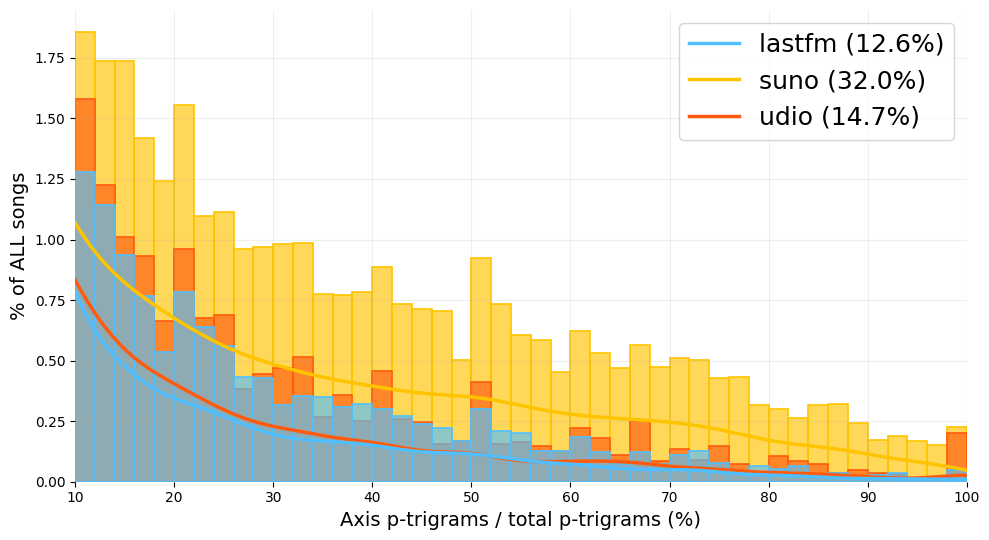


P-trigram axis classification
 Threshold Meaning                         lastfm              suno              udio
──────────────────────────────────────────────────────────────────────────────────────
      ≥50% axis dominates           434 (  2.3%)    1993 ( 10.5%)     562 (  3.0%)
      ≥25% strong axis             1195 (  6.3%)    3987 ( 21.0%)    1431 (  7.5%)
      ≥10% axis-based song         2392 ( 12.6%)    6076 ( 32.0%)    2791 ( 14.7%)
       ≥5% axis present            3355 ( 17.7%)    7225 ( 38.1%)    3719 ( 19.5%)
       ≥1% trace of axis           4950 ( 26.2%)    8809 ( 46.4%)    5023 ( 26.4%)
       >0% any axis p-trigram      5034 ( 26.6%)    8864 ( 46.7%)    5066 ( 26.6%)

ANSWER: Songs that are axis-based (≥10% axis p-trigrams)
  lastfm:  2392 / 18,916 (12.6%)
    suno:  6076 / 18,978 (32.0%)
    udio:  2791 / 19,031 (14.7%)


In [13]:
# ── 7. FINAL OVERLAY — all three collections on one panel ──
# Draw order: suno (back) → udio (middle) → lastfm (front)
# so the smallest distribution is always visible on top.
import matplotlib.colors as mcolors

DRAW_ORDER = ['suno', 'udio', 'lastfm']
fig, ax = plt.subplots(figsize=(10, 5.5))
for col in DRAW_ORDER:
    d = _plot_data[col]
    lbl = f'{col} ({d["frac_display"]*100:.1f}%)'

    # Histogram bars — transparent fill, fully opaque edges
    weights = np.ones_like(d['pcts_display']) / d['n_all'] * 100
    face = mcolors.to_rgba(colors[col], alpha=0.65)
    ax.hist(d['pcts_display'], bins=BINS, weights=weights,
        facecolor=face, edgecolor=colors[col], linewidth=1.2)

    # KDE — fitted on ALL >0% data, displayed ≥10%
    if len(d['pcts_all']) >= 2:
        kde = gaussian_kde(d['pcts_all'], bw_method=BW)
        ys = kde(xs_plot) * d['frac_kde'] * 100
        ax.plot(xs_plot, ys, color=colors[col], linewidth=2.5, label=lbl)

ax.set_xlabel('Axis p-trigrams / total p-trigrams (%)', fontsize=14)
ax.set_ylabel('% of ALL songs', fontsize=14)
ax.set_title('', fontweight='bold', fontsize=14)
ax.set_xlim(10, 100)
# Reorder legend: always Lastfm, Suno, Udio
handles, labels = ax.get_legend_handles_labels()
label_order = {l: h for h, l in zip(handles, labels)}
ordered_handles = []
ordered_labels = []
for col in ['lastfm', 'suno', 'udio']:
    for l, h in label_order.items():
        if l.lower().startswith(col):
            ordered_handles.append(h)
            ordered_labels.append(l)
            break
ax.legend(ordered_handles, ordered_labels, fontsize=18)
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

# ── 8. Threshold table ──
thr_labels = [
    (50, '≥50%', 'axis dominates'),
    (25, '≥25%', 'strong axis'),
    (10, '≥10%', 'axis-based song'),
    (5,  '≥5%',  'axis present'),
    (1,  '≥1%',  'trace of axis'),
    (0.01, '>0%', 'any axis p-trigram'),
]
print('\nP-trigram axis classification')
print(f'{"Threshold":>10} {"Meaning":<20}', end='')
for col in COLLECTIONS:
    print(f'  {col:>16}', end='')
print()
print('─' * (32 + 3 * 18))
for thr, label, meaning in thr_labels:
    print(f'{label:>10} {meaning:<20}', end='')
    for col in COLLECTIONS:
        n   = len(ptri_stats[col])
        cnt = sum(1 for s in ptri_stats[col] if s['pct_axis'] >= thr)
        print(f'  {cnt:>6} ({cnt/n*100:>5.1f}%)', end='')
    print()

# ── 9. ANSWER ──
print('\n' + '=' * 72)
print('ANSWER: Songs that are axis-based (≥10% axis p-trigrams)')
print('=' * 72)
for col in COLLECTIONS:
    n   = len(ptri_stats[col])
    cnt = sum(1 for s in ptri_stats[col] if s['pct_axis'] >= 10)
    print(f'  {col:>6}: {cnt:>5} / {n:,} ({cnt/n*100:.1f}%)')
print('=' * 72)
